# FAST'26 Artifact Evaluation - Plotter

In [ ]:
# Prelude
# RUN THIS CELL BEFORE ANYTHING ELSE!

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import math
import os
import re

cwd = os.getcwd().split("/scripts")[0]
os.chdir(cwd)

# the process function for PipeANN and DiskANN.
# Input: the raw log file
# Output: a dict with key: system + dataset, value: 
# {
#  "search": [(time, p50, p90, p99, tput)], 
#  "acc": { "L0": [acc1, acc2, ...], "L1": [acc1, acc2, ...] }, 
#  "mem": {(time, mem) } 
# }
# In the file, each line contains:
# 1. [xxx (DO NOT USE THIS TO IDENTIFY)] search current time: {time}
# 2. ten numbers, L, QPS, mean lat, p50, p90, p95, p99, p999, recall, diskIO
# - if recall == 0 and L equal to default_L, then add to "search".
# - elif recall == 0, ignore it.
# - else, add to "acc" with the corresponding "L" key.
# - recall should / 100 (float).
# 3. [xxx (DO NOT USE THIS TO IDENTIFY)] memory current time: 16 RSS : 1.50359e+07 KB
# - add this to "mem" (convert to GB)
# 4. other, ignore it.
# If process errors, then output the error line and pause.

def parse_inserted_from_truthfile(truth_file):
    match = re.search(r"/gt_(\d+)\.bin", truth_file)
    if match:
        return int(match.group(1))
    return None


def process_pipeann(filename, default_L):
    current_data = {
        "search": [],
        "search_mean_latency": [],
        "acc": {},
        "mem": [],
        "insert_tput": [],
        "disk_space": 0
    }

    last_search_op_time = 0.0
    search_time_delta = 0 

    cur_truth_file = ""
    truth_set = {}

    with open(filename, "r") as f:
        for line_num, line_content in enumerate(f, 1):
            line = line_content.strip()
            if not line: 
                continue
            
            
            if "Index size" in line:
                idx_size = line.split("Index size")[1].strip().split()[0]
                current_data["disk_space"] = max(current_data["disk_space"], float(idx_size) / 1024) 
            
            if "search current time:" in line:
                time_str = line.split("search current time:")[1].strip()
                if not re.fullmatch(r"\d+(?:\.\d+)?", time_str):
                    continue
                current_time = float(time_str)
                if current_time < last_search_op_time:
                    search_time_delta += last_search_op_time
                last_search_op_time = current_time
                continue

            elif "memory current time:" in line and "RSS" in line:
                parts = line.split("memory current time:")[1].split("RSS :")
                mem_time_str = parts[0].strip()
                rss_kb_str = parts[1].split("KB")[0].strip()
                
                mem_time = float(mem_time_str)
                rss_kb = float(rss_kb_str)
                rss_gb = rss_kb / (1024 * 1024) 
                current_data["mem"].append((mem_time + search_time_delta, rss_gb))
                continue
            elif "Reading truthset file" in line:
                cur_truth_file = line.split()[-1]
            elif "tasks/sec" in line and "Processed" in line:
                
                
                tput = line.split("throughput:")[-1].strip().split()[0]
                current_data["insert_tput"].append(float(tput))
            else:
                try:
                    data_parts = line.split()
                    if len(data_parts) == 10:
                        values = [float(p) for p in data_parts]
                        
                        L_val = int(values[0])
                        QPS_val = values[1]
                        mean_val = values[2]
                        p50_val = values[3]
                        p90_val = values[4]
                        p99_val = values[6]
                        recall_val = values[8]
                        n_pages = values[9]

                        if recall_val == 0:
                            if L_val == default_L:
                                if last_search_op_time is not None:
                                    current_data["search"].append(
                                        (last_search_op_time + search_time_delta, p50_val, p90_val, p99_val, QPS_val)
                                    )
                                    current_data["search_mean_latency"].append(
                                        (last_search_op_time + search_time_delta, mean_val)
                                    )
                        else:
                            acc_value_float = recall_val / 100.0
                            acc_key = f"L{L_val}"
                            if acc_key not in current_data["acc"]:
                                current_data["acc"][acc_key] = []
                                current_data["acc"][acc_key + "_pages"] = []
                                current_data["acc"][acc_key + "_lat"] = []
                                current_data["acc"][acc_key + "_inserted"] = []
                            
                            if acc_key not in truth_set:
                                truth_set[acc_key] = set()
                            if cur_truth_file not in truth_set[acc_key]:
                                truth_set[acc_key].add(cur_truth_file)
                                inserted_count = parse_inserted_from_truthfile(cur_truth_file)
                                if inserted_count is None:
                                    inserted_count = len(current_data["acc"][acc_key])
                                current_data["acc"][acc_key].append(acc_value_float)
                                current_data["acc"][acc_key+"_pages"].append(n_pages)
                                current_data["acc"][acc_key+"_lat"].append(p50_val)
                                current_data["acc"][acc_key+"_inserted"].append(inserted_count)
                        
                        continue
                except:
                    continue

    return current_data




def process_spann(filename, L):
    sec_search = []
    sec_memory = []
    acc = []
    disk_space = 0

    def rdln(f):
        ret = f.readline()
        if not ret: 
            return None
        return ret.strip()

    ret = {}
    with open(filename, "r") as f:
        cur_sec = 0
        cur_truthset = ""
        while f:
            line = rdln(f)
            if line is None:
                break
            line = line.strip()
            split_line = line.split()

            if line.startswith("[1] Current time:") and "Searching Times" in line:
                tput_item = [int(split_line[3][:-1]), float(split_line[-1][:-1])] 
                lat_item = []
                while True:
                    line = rdln(f)
                    if "Total Latency Distribution" in line:
                        while True:
                            line = rdln(f)
                            try:
                                split_line = line.split()
                                if len(split_line) == 8:
                                    lat_item = [float(split_line[2]), float(split_line[3]), float(split_line[5])] 
                                else:
                                    continue
                                break
                            except:
                                pass
                        break
                item = [tput_item[0]] + lat_item + [tput_item[1]] 
                sec_search.append(item)
            elif line.startswith("[1] Current time"):
                cur_sec = int(split_line[3][:-1])
                sec_memory.append((int(split_line[3][:-1]), int(split_line[-2]) / 1000))
            elif line.startswith("[1] Remain"):
                disk_space = max(disk_space, 1700 - int(split_line[-2]))
            elif "Recall10@10" in line:
                acc.append(float(split_line[-1])) 

    ret = {
        "search": sec_search,
        "acc": {
            f"L{L}": acc
        },
        "mem": sec_memory,
        "disk_space": disk_space,
    }
    return ret

def downsample_median(x_data, y_data_list_input, max_npts):
    x_data = np.array(x_data) 

    y_data_list = []
    if not isinstance(y_data_list_input, list):
        y_data_list = [np.array(y_data_list_input)] 
    else:
        for y_d in y_data_list_input:
            y_data_list.append(np.array(y_d)) 

    n_points = len(x_data)

    if n_points == 0 or max_npts is None or max_npts <= 0 or n_points <= max_npts:
        return x_data, y_data_list 

    
    chunk_size = math.ceil(n_points / max_npts)
    chunk_size = max(1, int(chunk_size)) 

    x_downsampled_list = []
    y_downsampled_lists_of_lists = [[] for _ in y_data_list]

    for i in range(0, n_points, chunk_size):
        start_idx = i
        end_idx = min(i + chunk_size, n_points)

        if start_idx >= end_idx: 
            continue

        x_chunk = x_data[start_idx:end_idx]
        x_downsampled_list.append(np.median(x_chunk))

        for j, y_data_single_series in enumerate(y_data_list):
            y_chunk = y_data_single_series[start_idx:end_idx]
            y_downsampled_lists_of_lists[j].append(np.median(y_chunk))
            
    x_downsampled_arr = np.array(x_downsampled_list)
    y_downsampled_list_result = [np.array(y_l) for y_l in y_downsampled_lists_of_lists]
            
    return x_downsampled_arr, y_downsampled_list_result

def plot_performance_dashboard(fig, axs, data, default_L, system_label, line_color, max_npts=None, lat_max = 15, tput_max = 7000, acc_max = 0.9, mem_max = 70, latency_plot = "line", box_position = None):
    search_data = data.get("search", [])
    acc_data_all = data.get("acc", {})
    mem_data = data.get("mem", [])

    
    times_search_orig = np.array([item[0] for item in search_data]) if search_data else np.array([])
    p50_lat_orig = np.array([item[1] for item in search_data]) if search_data else np.array([])
    p90_lat_orig = np.array([item[2] for item in search_data]) if search_data else np.array([])
    p99_lat_orig = np.array([item[3] for item in search_data]) if search_data else np.array([])
    throughputs_orig = np.array([item[4] for item in search_data]) if search_data else np.array([])

    
    if times_search_orig.size > 0:
        times_search, y_search_ds_list = downsample_median(
            times_search_orig,
            [p50_lat_orig, p90_lat_orig, p99_lat_orig, throughputs_orig],
            max_npts
        )
        p50_lat, p90_lat, p99_lat, throughputs = y_search_ds_list[0], y_search_ds_list[1], y_search_ds_list[2], y_search_ds_list[3]
    else:
        times_search, p50_lat, p90_lat, p99_lat, throughputs = \
            times_search_orig, p50_lat_orig, p90_lat_orig, p99_lat_orig, throughputs_orig


    def plot_latency_panel(ax, line_values, box_values, title):
        if latency_plot == "box":
            box_values = box_values[np.isfinite(box_values)]
            if box_values.size > 0:
                position = box_position if box_position is not None else 1
                ax.boxplot(
                    [box_values],
                    positions=[position],
                    widths=0.55,
                    patch_artist=True,
                    showfliers=False,
                    boxprops=dict(facecolor=line_color, color=line_color, alpha=0.35),
                    medianprops=dict(color=line_color, linewidth=2),
                    whiskerprops=dict(color=line_color),
                    capprops=dict(color=line_color),
                )
                ax.plot([], [], color=line_color, label=system_label)
            ax.set_xlabel("System")
        else:
            if times_search.size > 0:
                ax.plot(times_search, line_values, color=line_color, label=system_label)
            ax.set_xlabel("Elapsed Time (s)")
            ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)

        ax.set_title(title)
        ax.set_ylabel("Latency (ms)")
        ax.set_ylim(0, lat_max)
        ax.grid(True, linestyle='--', alpha=0.7)

    plot_latency_panel(axs[0, 0], p50_lat, p50_lat_orig, "(a) Search P50 Latency")
    plot_latency_panel(axs[0, 1], p90_lat, p90_lat_orig, "(b) Search P90 Latency")
    plot_latency_panel(axs[0, 2], p99_lat, p99_lat_orig, "(c) Search P99 Latency")

    
    ax = axs[1, 0]
    if times_search.size > 0:
        ax.plot(times_search, throughputs, color=line_color, label=system_label)
    ax.set_title("(d) Search Throughput")
    ax.set_xlabel("Elapsed Time (s)")
    ax.set_ylabel("Throughput (Op/s)")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}k' if x >= 1000 else f'{int(x)}'))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
    ax.set_ylim(0, tput_max)
    ax.grid(True, linestyle='--', alpha=0.7)

    
    ax = axs[1, 1]
    acc_key = f"L{default_L}"
    acc_values_orig = np.array(acc_data_all.get(acc_key, []))
    vectors_inserted_orig = np.array(acc_data_all.get(acc_key + "_inserted", []), dtype=float)
    if vectors_inserted_orig.size == 0 and acc_values_orig.size > 0:
        vectors_inserted_orig = np.arange(len(acc_values_orig), dtype=float)
    vectors_inserted_m_orig = vectors_inserted_orig / 1_000_000.0

    if acc_values_orig.size > 0:
        vectors_inserted_m, acc_values_ds_list = downsample_median(
            vectors_inserted_m_orig,
            [acc_values_orig], 
            max_npts
        )
        acc_values = acc_values_ds_list[0] 
        ax.plot(vectors_inserted_m, acc_values, color=line_color, label=system_label)
    
    
    ax.set_title("(e) Search Accuracy")
    ax.set_xlabel("Vectors Inserted (M)") 
    ax.set_ylabel(f"Recall @10")
    ax.set_ylim(0, acc_max)
    ax.grid(True, linestyle='--', alpha=0.7)

    
    ax = axs[1, 2]
    times_mem = np.array([]) 
    mem_usage_gb = np.array([])
    if mem_data:
        sorted_mem_data = sorted(mem_data, key=lambda x: x[0])
        times_mem_orig = np.array([item[0] for item in sorted_mem_data])
        mem_usage_gb_orig = np.array([item[1] for item in sorted_mem_data])

        if times_mem_orig.size > 0:
            times_mem, mem_usage_gb_ds_list = downsample_median(
                times_mem_orig,
                [mem_usage_gb_orig], 
                max_npts
            )
            mem_usage_gb = mem_usage_gb_ds_list[0] 
            ax.plot(times_mem, mem_usage_gb, color=line_color, label=system_label)
    
            
    ax.set_title("(f) Memory Usage")
    ax.set_xlabel("Elapsed Time (s)")
    ax.set_ylabel("Memory (GB)")
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)
    ax.set_ylim(0, mem_max)
    ax.grid(True, linestyle='--', alpha=0.7)

def plot_search_latency_boxplot(data, labels, colors=None, percentiles=("p50", "p90", "p99"), y_max=None, showfliers=False, figsize=None, box_spacing=1.0, box_width=0.55, recall_key="L20"):
    if isinstance(data, dict):
        data = [data]
    if isinstance(percentiles, str):
        percentiles = (percentiles,)
    if len(data) != len(labels):
        raise ValueError("data and labels must have the same length")

    metric_sources = {
        "avg": ("search_mean_latency", 1, "Avg"),
        "mean": ("search_mean_latency", 1, "Avg"),
        "p50": ("search", 1, "P50"),
        "p90": ("search", 2, "P90"),
        "p99": ("search", 3, "P99"),
        "recall": ("recall", None, "Recall"),
    }
    percentiles = tuple(p.lower() for p in percentiles)
    for percentile in percentiles:
        if percentile not in metric_sources:
            raise ValueError(f"unsupported boxplot metric: {percentile}")

    if colors is None or len(colors) == 0:
        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    if figsize is None:
        figsize = (4 * len(percentiles), 4)

    fig, axes = plt.subplots(1, len(percentiles), figsize=figsize, squeeze=False)
    axes = axes[0]
    positions = 1 + np.arange(len(labels)) * box_spacing

    for ax, percentile in zip(axes, percentiles):
        source_key, value_idx, metric_label = metric_sources[percentile]
        box_data = []
        box_positions = []
        box_colors = []

        for color_idx, (pos, parsed_data) in enumerate(zip(positions, data)):
            color = colors[color_idx % len(colors)]
            if source_key == "recall":
                values = np.array(parsed_data.get("acc", {}).get(recall_key, []), dtype=float)
            else:
                values = np.array([item[value_idx] for item in parsed_data.get(source_key, [])], dtype=float)
            values = values[np.isfinite(values)]
            if values.size == 0:
                continue
            box_data.append(values)
            box_positions.append(pos)
            box_colors.append(color)

        if box_data:
            box = ax.boxplot(box_data, positions=box_positions, widths=box_width, patch_artist=True, showfliers=showfliers)
            for patch, color in zip(box["boxes"], box_colors):
                patch.set_facecolor(color)
                patch.set_edgecolor(color)
                patch.set_alpha(0.35)
            for median, color in zip(box["medians"], box_colors):
                median.set_color(color)
                median.set_linewidth(2)
            for whisker_idx, whisker in enumerate(box["whiskers"]):
                whisker.set_color(box_colors[whisker_idx // 2])
            for cap_idx, cap in enumerate(box["caps"]):
                cap.set_color(box_colors[cap_idx // 2])

        ax.set_title(metric_label)
        # ax.set_ylabel("Latency (ms)")
        ax.set_xticks([])
        ax.set_xlabel("")
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
        if isinstance(y_max, dict):
            metric_y_max = y_max.get(percentile)
        else:
            metric_y_max = y_max
        if metric_y_max is not None:
            if isinstance(metric_y_max, (tuple, list)):
                ax.set_ylim(metric_y_max[0], metric_y_max[1])
            else:
                ax.set_ylim(0, metric_y_max)
        ax.set_xlim(positions[0] - box_width, positions[-1] + box_width)
        ax.grid(True, linestyle='--', alpha=0.7)

    fig.tight_layout()
    return fig, axes

def plot_search_latency_boxplot_from_files(filenames, labels, default_L, colors=None, **kwargs):
    data = [process_pipeann(filename, default_L) for filename in filenames]
    return plot_search_latency_boxplot(data, labels, colors=colors, **kwargs)

def save_figure(fig, output_dir, basename, formats=("png",), dpi=300):
    if isinstance(formats, str):
        formats = (formats,)

    os.makedirs(output_dir, exist_ok=True)
    saved_paths = []
    for fmt in formats:
        fmt = fmt.lstrip(".")
        output_path = os.path.join(output_dir, f"{basename}.{fmt}")
        fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
        saved_paths.append(output_path)
    return saved_paths

def save_search_latency_boxplots(data, labels, colors, output_dir, prefix="fig6_search_latency_boxplot", metrics=("avg", "p90", "p99", "recall"), y_max=None, showfliers=False, formats=("png", "pdf"), dpi=300, combined_fig=None, box_spacing=1.0, box_width=0.55, figure_wspace=None, recall_key="L20", close_individual=True):
    saved_paths = []
    if combined_fig is not None:
        saved_paths.extend(save_figure(combined_fig, output_dir, f"{prefix}_all", formats=formats, dpi=dpi))

    for metric in metrics:
        fig_metric, _ = plot_search_latency_boxplot(
            data,
            labels,
            colors,
            percentiles=(metric,),
            y_max=y_max,
            showfliers=showfliers,
            figsize=(max(5, 1.8 * len(labels)), 4),
            box_spacing=box_spacing,
            box_width=box_width,
            recall_key=recall_key,
        )
        if figure_wspace is not None:
            fig_metric.subplots_adjust(wspace=figure_wspace)
        saved_paths.extend(save_figure(fig_metric, output_dir, f"{prefix}_{metric}", formats=formats, dpi=dpi))
        if close_individual:
            plt.close(fig_metric)

    return saved_paths

def plot_search_mean_latency_boxplot(data, labels, colors=None, y_max=None, showfliers=False, figsize=None, box_spacing=1.0, box_width=0.55):
    if isinstance(data, dict):
        data = [data]
    if len(data) != len(labels):
        raise ValueError("data and labels must have the same length")

    if colors is None or len(colors) == 0:
        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    if figsize is None:
        figsize = (max(5, 1.8 * len(labels)), 4)

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    positions = 1 + np.arange(len(labels)) * box_spacing
    box_data = []
    box_positions = []
    box_colors = []

    for color_idx, (pos, parsed_data) in enumerate(zip(positions, data)):
        color = colors[color_idx % len(colors)]
        values = np.array([item[1] for item in parsed_data.get("search_mean_latency", [])], dtype=float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue
        box_data.append(values)
        box_positions.append(pos)
        box_colors.append(color)

    if box_data:
        box = ax.boxplot(box_data, positions=box_positions, widths=box_width, patch_artist=True, showfliers=showfliers)
        for patch, color in zip(box["boxes"], box_colors):
            patch.set_facecolor(color)
            patch.set_edgecolor(color)
            patch.set_alpha(0.35)
        for median, color in zip(box["medians"], box_colors):
            median.set_color(color)
            median.set_linewidth(2)
        for whisker_idx, whisker in enumerate(box["whiskers"]):
            whisker.set_color(box_colors[whisker_idx // 2])
        for cap_idx, cap in enumerate(box["caps"]):
            cap.set_color(box_colors[cap_idx // 2])

    ax.set_title("Search Mean Latency")
    ax.set_ylabel("Latency (ms)")
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
    ax.set_xlim(positions[0] - box_width, positions[-1] + box_width)
    if y_max is not None:
        ax.set_ylim(0, y_max)
    ax.grid(True, linestyle='--', alpha=0.7)
    fig.tight_layout()
    return fig, ax

sysname = [
    "OdinANN",
    "DiskANN",
    "SPFresh"
]

colors = [
    "red",
    "blue",
    "purple"
]

## Figure 6

This figure requires that you run `fig6.sh` beforehand.

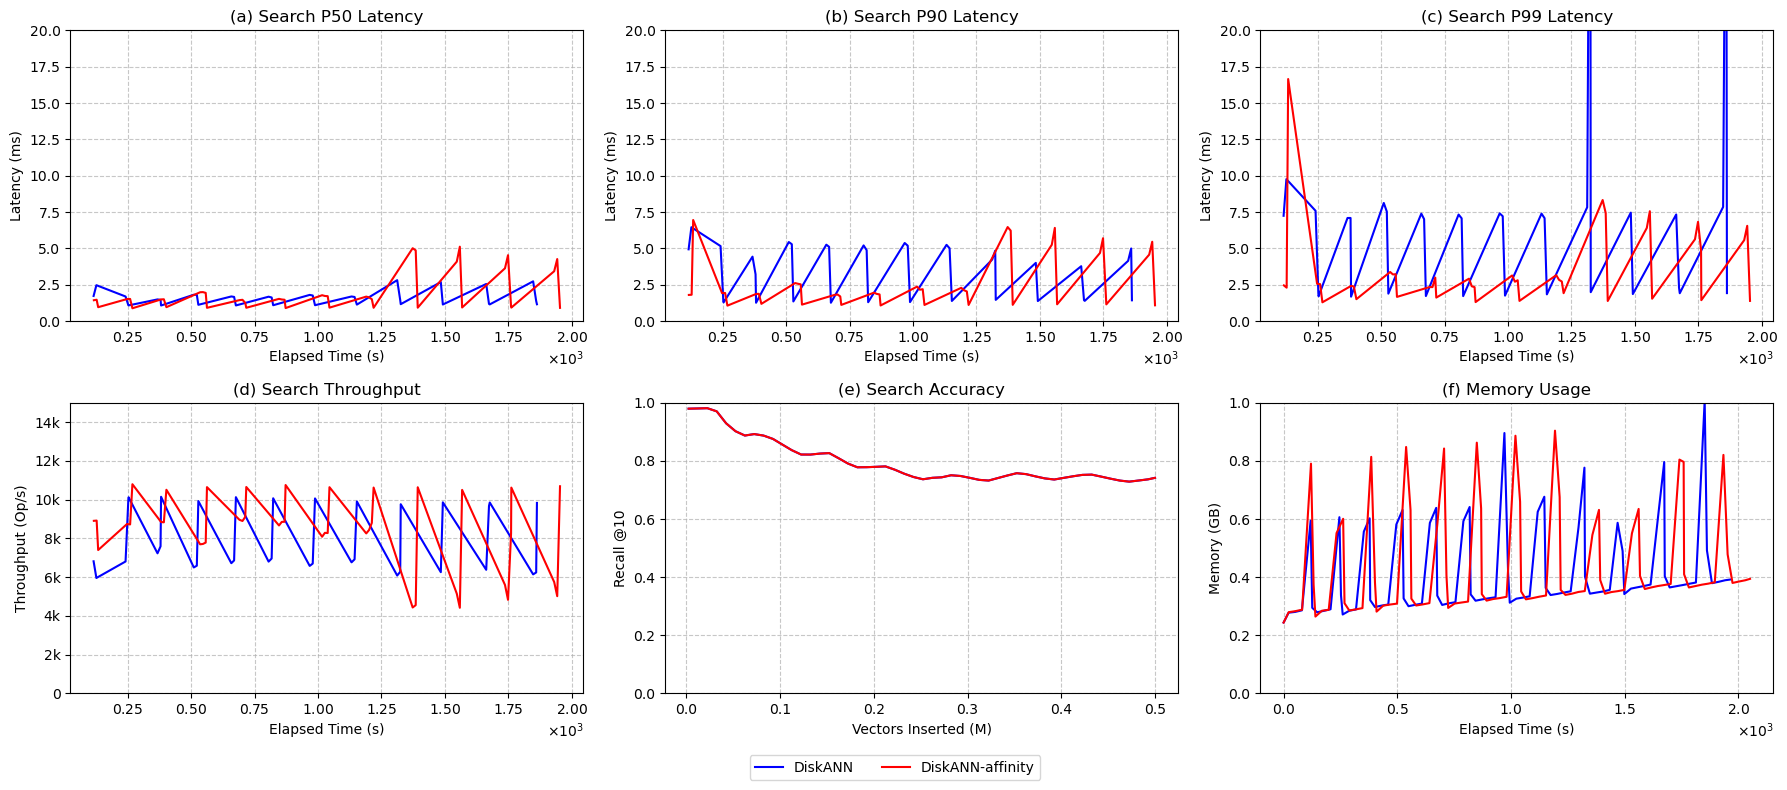

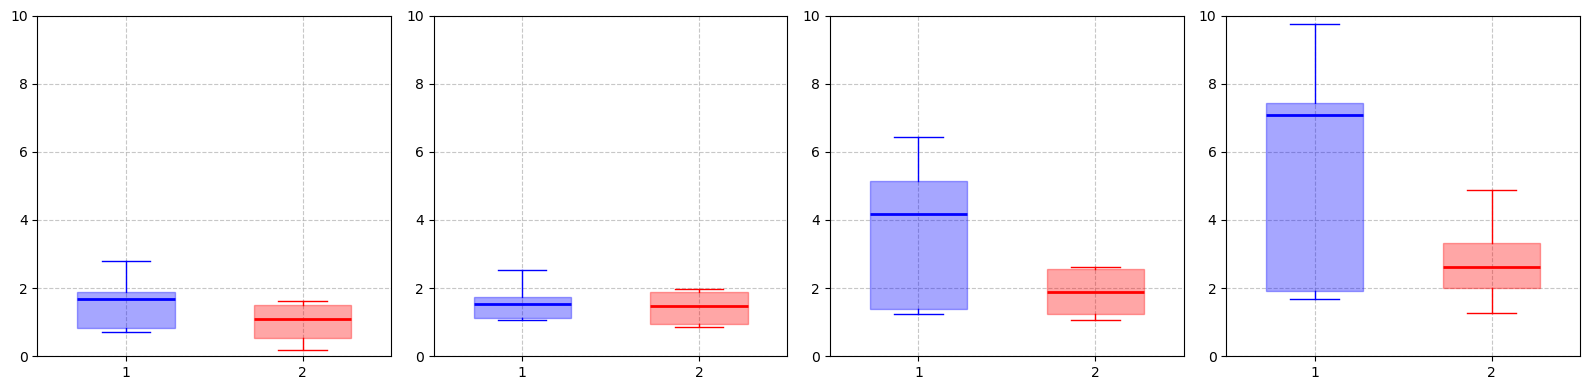

In [20]:
USE_EXAMPLE = False
filename_prefix = "./scripts/tests-odinann/data-example" if USE_EXAMPLE else "./scripts/tests-odinann/data"
DEFAULT_L = 20
SHOW_LATENCY_BOXPLOT = True
SAVE_BOXPLOT_FIGURES = True
SAVE_COMBINED_BOXPLOT_FIGURE = True
SAVE_INDIVIDUAL_BOXPLOT_FIGURES = True
BOXPLOT_METRICS = ("avg", "p90", "p99", "recall")
BOXPLOT_RECALL_KEY = f"L{DEFAULT_L}"
BOXPLOT_Y_MAX = {"avg": 10, "p90": 10, "p99": 10, "recall": 1.0}
BOXPLOT_BOX_SPACING = 0.7  # 1.0 is the original spacing; smaller values move boxes closer.
BOXPLOT_BOX_WIDTH = 0.55
BOXPLOT_FIGURE_WSPACE = 0.45
BOXPLOT_OUTPUT_DIR = "./scripts/tests-odinann/figures"
BOXPLOT_OUTPUT_FORMATS = ("png", "pdf")
BOXPLOT_DPI = 300
plot_names = ["DiskANN", "DiskANN-affinity"]
plot_colors = ["blue", "red", "green"]

data = [
    process_pipeann(filename_prefix + "/DiskANN-insertonly-sift1m_32-2-24_15-15.txt", DEFAULT_L),
    process_pipeann(filename_prefix + "/DiskANN-insertonly-sift1m_affinity_32-2-24_15-15.txt", DEFAULT_L),
]

fig, axs = plt.subplots(2, 3, figsize=(18, 8))
for name, parsed_data, color in zip(plot_names, data, plot_colors):
    plot_performance_dashboard(fig, axs, parsed_data, DEFAULT_L, name, color, 100, 20, 15000, 1, 1)

handles, labels = [], []
for ax_row in axs:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        for i, label_item in enumerate(l):
            if label_item not in labels: 
                labels.append(label_item)
                handles.append(h[i])

if handles: 
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) 

if SHOW_LATENCY_BOXPLOT:
    fig_box, axs_box = plot_search_latency_boxplot(
        data,
        plot_names,
        plot_colors,
        percentiles=BOXPLOT_METRICS,
        y_max=BOXPLOT_Y_MAX,
        box_spacing=BOXPLOT_BOX_SPACING,
        box_width=BOXPLOT_BOX_WIDTH,
        recall_key=BOXPLOT_RECALL_KEY,
    )
    fig_box.subplots_adjust(wspace=BOXPLOT_FIGURE_WSPACE)

    if SAVE_BOXPLOT_FIGURES:
        saved_boxplot_files = save_search_latency_boxplots(
            data,
            plot_names,
            plot_colors,
            BOXPLOT_OUTPUT_DIR,
            metrics=BOXPLOT_METRICS if SAVE_INDIVIDUAL_BOXPLOT_FIGURES else (),
            y_max=BOXPLOT_Y_MAX,
            formats=BOXPLOT_OUTPUT_FORMATS,
            dpi=BOXPLOT_DPI,
            combined_fig=fig_box if SAVE_COMBINED_BOXPLOT_FIGURE else None,
            box_spacing=BOXPLOT_BOX_SPACING,
            box_width=BOXPLOT_BOX_WIDTH,
            figure_wspace=BOXPLOT_FIGURE_WSPACE,
            recall_key=BOXPLOT_RECALL_KEY,
        )
        print("Saved boxplot figures:")
        for output_path in saved_boxplot_files:
            print(output_path)


## Figure 7

This figure requires that you run `fig7.sh` beforehand.

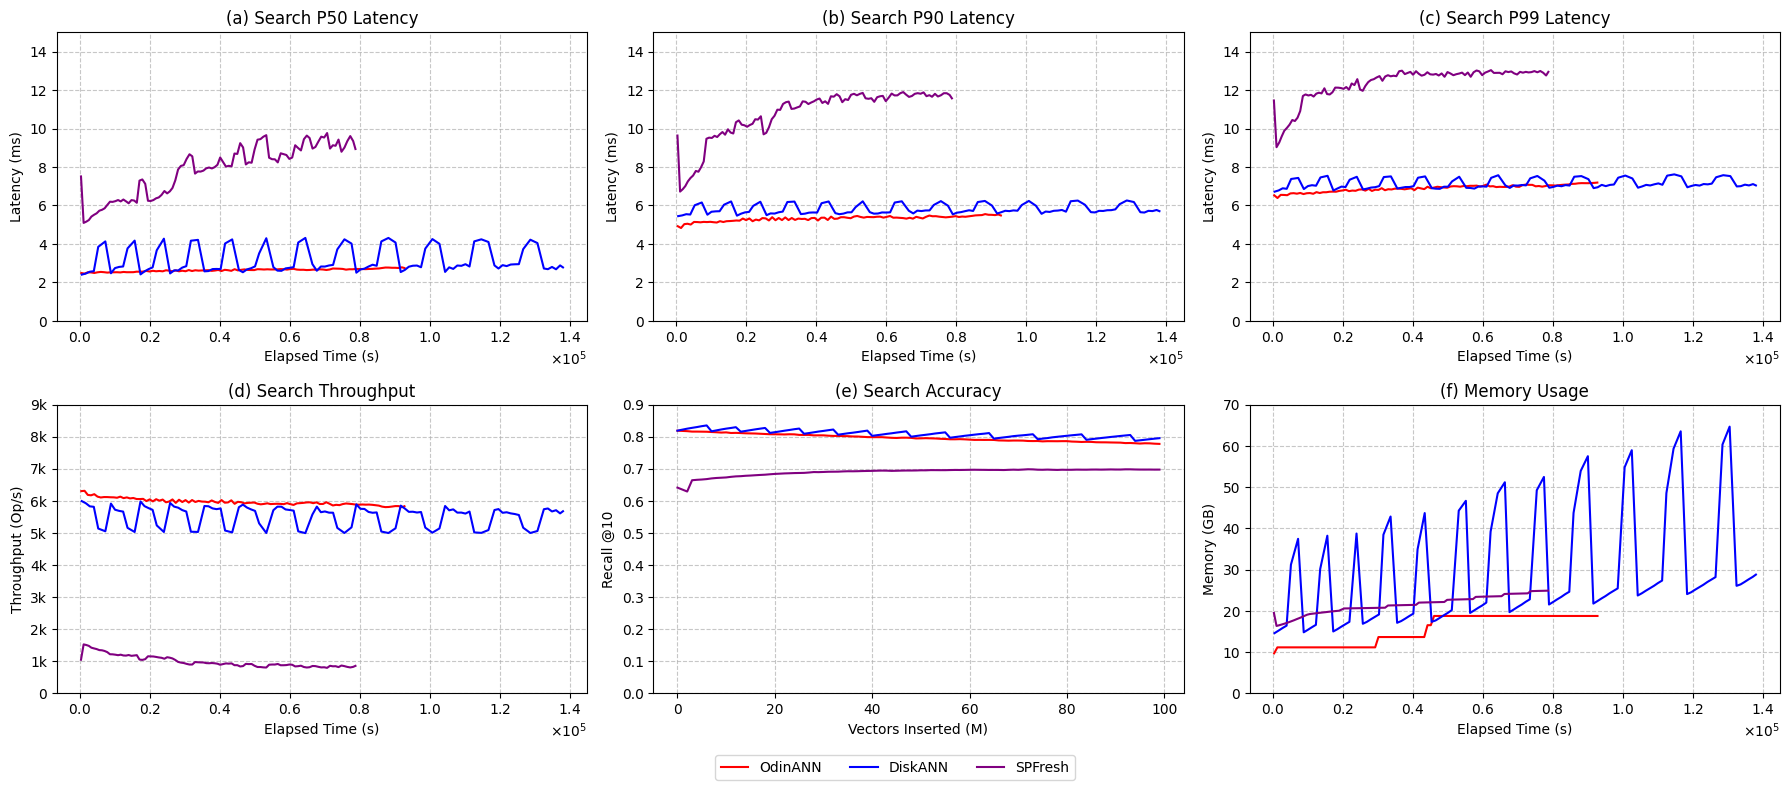

In [4]:
USE_EXAMPLE = True
filename_prefix = "./data-example" if USE_EXAMPLE else "./data"
DEFAULT_L = 25

data = [
    process_pipeann(filename_prefix + "/OdinANN-insertonly-deep.txt", DEFAULT_L),
    process_pipeann(filename_prefix + "/DiskANN-insertonly-deep.txt", DEFAULT_L),
    process_spann(filename_prefix + "/SPFresh-insertonly-deep.txt", DEFAULT_L)
]

fig, axs = plt.subplots(2, 3, figsize=(18, 8))
for name, parsed_data, color in zip(sysname, data, colors):
    plot_performance_dashboard(fig, axs, parsed_data, DEFAULT_L, name, color, 100, 15, 9000, 0.9, 70)

handles, labels = [], []
for ax_row in axs:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        for i, label_item in enumerate(l):
            if label_item not in labels: 
                labels.append(label_item)
                handles.append(h[i])

if handles: 
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) 

## Figure 8

This figure requires that you run `fig8.sh` beforehand.

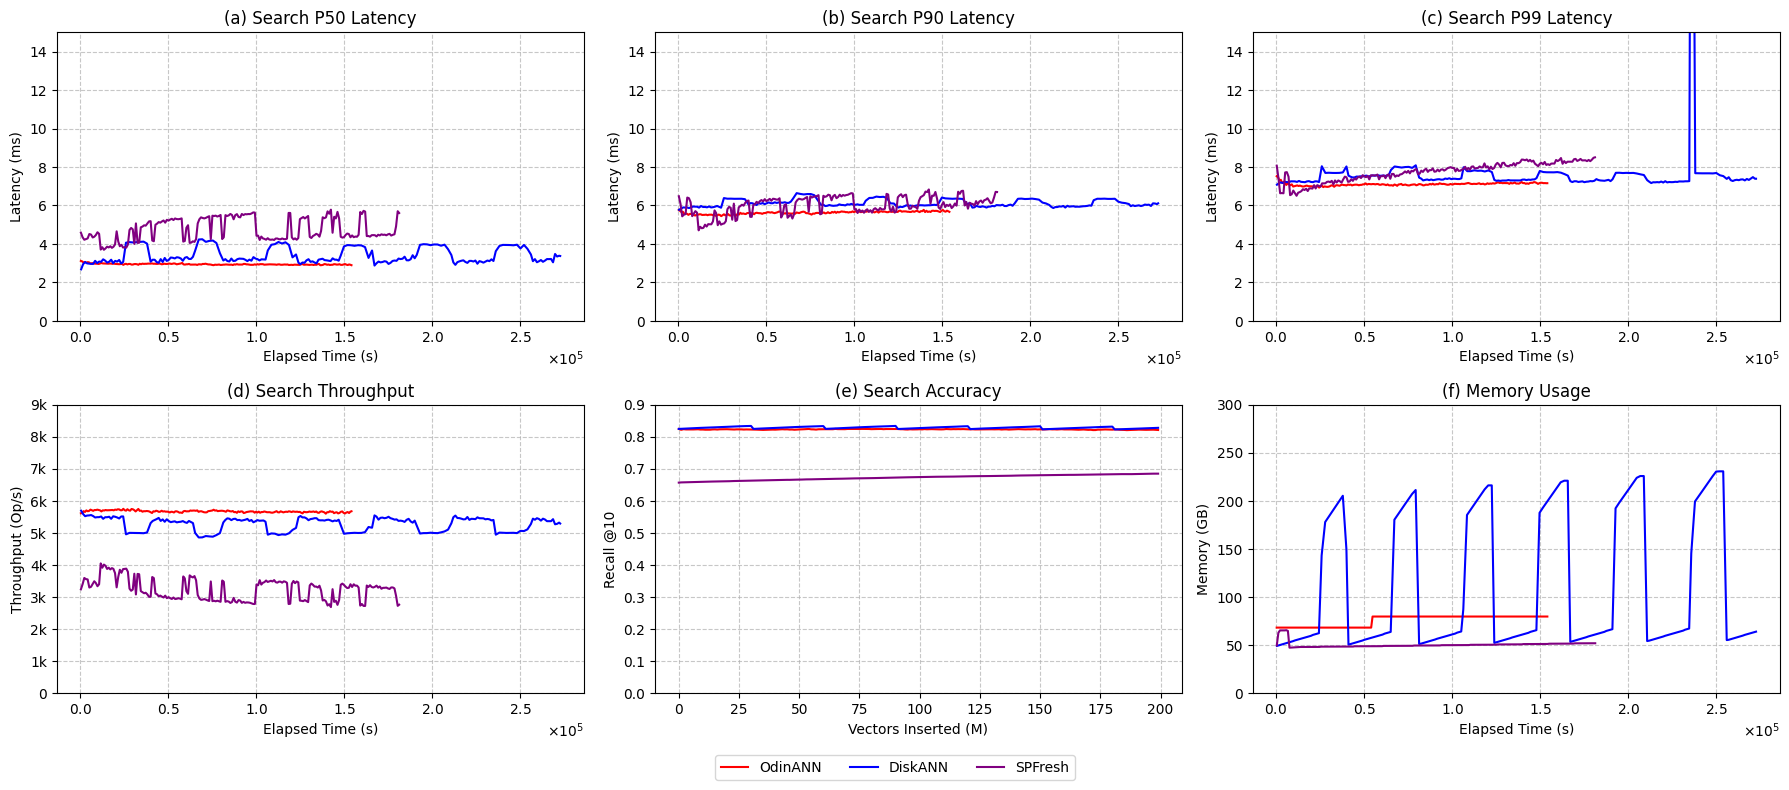

In [5]:
USE_EXAMPLE = True
filename_prefix = "./data-example" if USE_EXAMPLE else "./data"
DEFAULT_L = 25

data = [
    process_pipeann(filename_prefix + "/OdinANN-stress.txt", DEFAULT_L),
    process_pipeann(filename_prefix + "/DiskANN-stress.txt", DEFAULT_L),
    process_spann(filename_prefix + "/SPFresh-stress.txt", DEFAULT_L)
]

fig, axs = plt.subplots(2, 3, figsize=(18, 8))
for name, parsed_data, color in zip(sysname, data, colors):
    plot_performance_dashboard(fig, axs, parsed_data, DEFAULT_L, name, color, 200, 15, 9000, 0.9, 300)

handles, labels = [], []
for ax_row in axs:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        for i, label_item in enumerate(l):
            if label_item not in labels: 
                labels.append(label_item)
                handles.append(h[i])

if handles: 
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) 

## Figure 9

This figure requires that you run `fig9.sh` beforehand.

/tmp/ipykernel_2851614/3145046303.py:67: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  legend_handles = [plt.Rectangle((0,0),1,1, color=color, edgecolor='black', linewidth=0.5) for color in cur_colors]


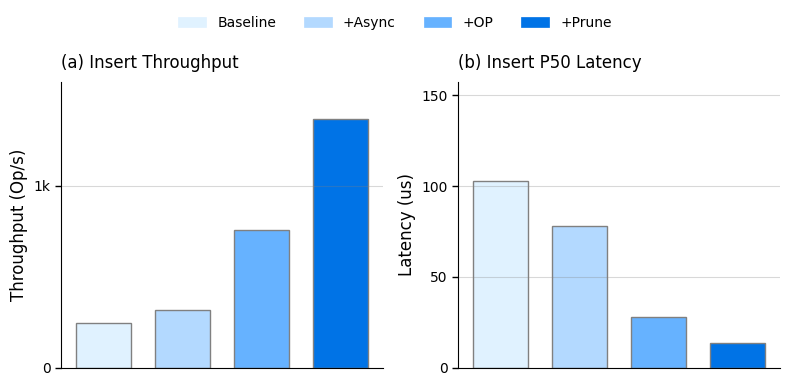

In [6]:
USE_EXAMPLE = True
filename_prefix = "./data-example" if USE_EXAMPLE else "./data"

def process_file(filename):
    with open(filename, "r") as f:
        lines = f.readlines()
    tput = 0
    p50_lat = 0
    for line in lines:
        if "Inserted" in line and "points in" in line:
            parts = line.split("Inserted")[1].split()
            num_points = int(parts[0])
            time_taken = float(parts[3][:-1])
            tput = num_points / time_taken
        elif "50p insertion time :" in line:
            p50_lat = float(line.split()[-2]) / 1000
    return (tput, p50_lat)

data = [
    process_file(filename_prefix + "/Baseline-insertonly-sift.txt"),
    process_file(filename_prefix + "/Async-insertonly-sift.txt"),
    process_file(filename_prefix + "/Op-insertonly-sift.txt"),
    process_file(filename_prefix + "/Prune-insertonly-sift.txt")
]

throughputs = [item[0] for item in data]
p50_latencies = [item[1] for item in data]
categories = ['Baseline', '+Async', '+OP', '+Prune']
cur_colors = ['#E0F2FF', '#B3D9FF', '#66B2FF', '#0073E6'] # Light to dark blue
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4)) 

bar_width = 0.7 
x_positions = np.arange(len(categories))
ax1.bar(x_positions, throughputs, width=bar_width, color=cur_colors, edgecolor='grey')
ax1.set_ylabel('Throughput (Op/s)', fontsize=12)
ax1.set_title('(a) Insert Throughput', fontsize=12, loc='left', pad=10) 

ax1.set_xticks(x_positions)
ax1.set_xticklabels([]) 
ax1.set_yticks([0, 1000, 2000])
ax1.set_yticklabels(['0', '1k', '2k'], fontsize=10)
ax1.set_ylim(0, max(throughputs) * 1.15) 

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='y', direction='out', length=4, width=1)
ax1.tick_params(axis='x', length=0) 
ax1.grid(axis='y', linestyle='-', alpha=0.3, color='grey') 

ax2.bar(x_positions, p50_latencies, width=bar_width, color=cur_colors, edgecolor='grey')
ax2.set_ylabel('Latency (us)', fontsize=12)
ax2.set_title('(b) Insert P50 Latency', fontsize=12, loc='left', pad=10)

ax2.set_xticks(x_positions)
ax2.set_xticklabels([]) 

ax2.set_yticks([0, 50, 100, 150])
ax2.set_yticklabels(['0', '50', '100', '150'], fontsize=10)
ax2.set_ylim(0, 150 * 1.05) 

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='y', direction='out', length=4, width=1)
ax2.tick_params(axis='x', length=0) 
ax2.grid(axis='y', linestyle='-', alpha=0.3, color='grey') 

legend_handles = [plt.Rectangle((0,0),1,1, color=color, edgecolor='black', linewidth=0.5) for color in cur_colors]
fig.legend(legend_handles, categories, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=len(categories), frameon=False, fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 0.93]) 


plt.show()

## Figure 10

This figure requires that you run `fig6.sh` and `fig7.sh` beforehand.

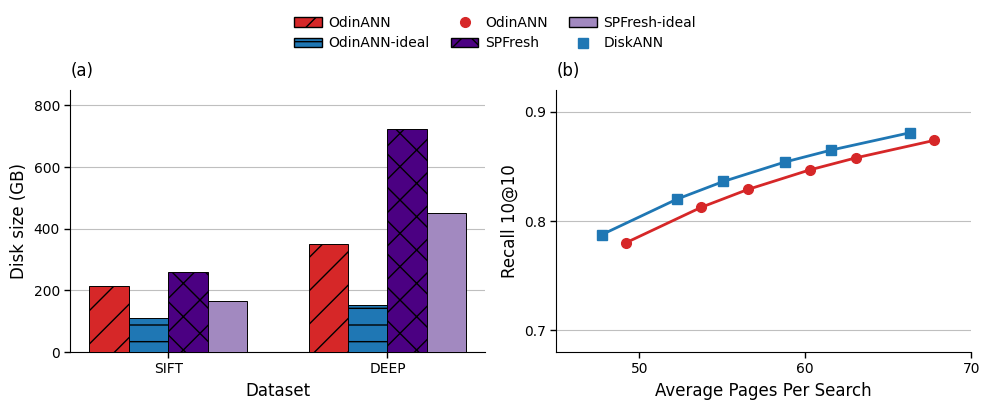

In [7]:
USE_EXAMPLE = True
filename_prefix = "./data-example" if USE_EXAMPLE else "./data"
DEFAULT_L_SIFT = 20
DEFAULT_L_DEEP = 25

data_sift = [
    process_pipeann(filename_prefix + "/OdinANN-insertonly-sift.txt", DEFAULT_L_SIFT),
    process_pipeann(filename_prefix + "/DiskANN-insertonly-sift.txt", DEFAULT_L_SIFT),
    process_spann(filename_prefix + "/SPFresh-insertonly-sift.txt", DEFAULT_L_SIFT)
]

data_deep = [
    process_pipeann(filename_prefix + "/OdinANN-insertonly-deep.txt", DEFAULT_L_DEEP),
    process_pipeann(filename_prefix + "/DiskANN-insertonly-deep.txt", DEFAULT_L_DEEP),
    process_spann(filename_prefix + "/SPFresh-insertonly-deep.txt", DEFAULT_L_DEEP)
]

disk_space_sift = [
    data_sift[0]["disk_space"],
    55 * 2,
    data_sift[2]["disk_space"],
    83 * 2
]

disk_space_deep = [
    data_deep[0]["disk_space"],
    77 * 2,
    data_deep[2]["disk_space"],
    226 * 2
]

recall_pages = []

for i in range(2):
    cur = []
    for k, v in data_deep[i]["acc"].items():
        if "_" not in k:
            cur.append((v[94], data_deep[i]["acc"][k.split("_")[0] + "_pages"][94]))
    recall_pages.append(cur)

import matplotlib.patches as mpatches 
from matplotlib.lines import Line2D 
odin_ann_recall = [item[0] for item in recall_pages[0]]
odin_ann_pages = [item[1] for item in recall_pages[0]]
disk_ann_recall = [item[0] for item in recall_pages[1]]
disk_ann_pages = [item[1] for item in recall_pages[1]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) 

# --- Define styles based on the image ---
# Panel (a) bar styles
colors_bars = ['#d62728', '#1f77b4', '#4B0082', '#A289C0'] # Red, Blue, DarkPurple, LightPurple
# Hatches: '/', '-', 'x', '' (no hatch for SPFresh-ideal)
# Note: Matplotlib hatch color is determined by edgecolor or can be set separately in newer versions.
# We'll use edgecolor for simplicity.
hatches_bars = ['/', '-', 'x', '']
bar_labels_a = ['OdinANN', 'OdinANN-ideal', 'SPFresh', 'SPFresh-ideal']

# Panel (b) line styles
colors_lines = ['#d62728', '#1f77b4'] # Red, Blue
markers_lines = ['o', 's']
line_labels_b = ['OdinANN', 'DiskANN']

datasets_a = ['SIFT', 'DEEP']
num_datasets_a = len(datasets_a)
num_methods_a = len(bar_labels_a)
bar_width_a = 0.18  
group_width_a = bar_width_a * num_methods_a
x_a = np.arange(num_datasets_a) 

for i in range(num_methods_a):
    bar_positions = x_a + (i - num_methods_a / 2 + 0.5) * bar_width_a
    values = [disk_space_sift[i], disk_space_deep[i]]
    ax1.bar(bar_positions, values, width=bar_width_a,
            color=colors_bars[i], hatch=hatches_bars[i],
            edgecolor='black', linewidth=0.7, zorder=3) 

ax1.set_ylabel('Disk size (GB)', fontsize=12)
ax1.set_xlabel('Dataset', fontsize=12)
ax1.set_title('(a)', loc='left', fontsize=12, pad=10)
ax1.set_xticks(x_a)
ax1.set_xticklabels(datasets_a, fontsize=10)
ax1.set_yticks(np.arange(0, 801, 200))
ax1.set_yticklabels([str(int(t)) for t in np.arange(0, 801, 200)], fontsize=10)
ax1.set_ylim(0, 850)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='both', direction='out', length=4, width=1)
ax1.grid(axis='y', linestyle='-', alpha=0.5, color='grey', zorder=0)

ax2.plot(odin_ann_pages, odin_ann_recall, marker=markers_lines[0], color=colors_lines[0],
         label=line_labels_b[0], markersize=7, linewidth=2, zorder=3)
ax2.plot(disk_ann_pages, disk_ann_recall, marker=markers_lines[1], color=colors_lines[1],
         label=line_labels_b[1], markersize=7, linewidth=2, zorder=3)

ax2.set_ylabel('Recall 10@10', fontsize=12) 
ax2.set_xlabel('Average Pages Per Search', fontsize=12)
ax2.set_title('(b)', loc='left', fontsize=12, pad=10)

ax2.set_xticks(np.arange(50, 71, 10))
ax2.set_xticklabels([str(int(t)) for t in np.arange(50, 71, 10)], fontsize=10)
ax2.set_yticks(np.arange(0.7, 0.91, 0.1))
ax2.set_yticklabels([f"{t:.1f}" for t in np.arange(0.7, 0.91, 0.1)], fontsize=10)
ax2.set_xlim(45, 70) 
ax2.set_ylim(0.68, 0.92) 

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(axis='both', direction='out', length=4, width=1)
ax2.grid(axis='y', linestyle='-', alpha=0.5, color='grey', zorder=0)

legend_handles = [
    mpatches.Patch(facecolor=colors_bars[0], hatch=hatches_bars[0], edgecolor='black', label=bar_labels_a[0]), 
    mpatches.Patch(facecolor=colors_bars[2], hatch=hatches_bars[2], edgecolor='black', label=bar_labels_a[2]), 
    mpatches.Patch(facecolor=colors_bars[1], hatch=hatches_bars[1], edgecolor='black', label=bar_labels_a[1]), 
    mpatches.Patch(facecolor=colors_bars[3], hatch=hatches_bars[3], edgecolor='black', label=bar_labels_a[3]), 
    Line2D([0], [0], marker=markers_lines[0], color=colors_lines[0], label=line_labels_b[0], linestyle='None', markersize=7), 
    Line2D([0], [0], marker=markers_lines[1], color=colors_lines[1], label=line_labels_b[1], linestyle='None', markersize=7)  
]

ordered_handles = [
    mpatches.Patch(facecolor=colors_bars[0], hatch=hatches_bars[0], edgecolor='black'), 
    mpatches.Patch(facecolor=colors_bars[1], hatch=hatches_bars[1], edgecolor='black'), 
    Line2D([0], [0], marker=markers_lines[0], color=colors_lines[0], linestyle='None', markersize=7), 
    mpatches.Patch(facecolor=colors_bars[2], hatch=hatches_bars[2], edgecolor='black'), 
    mpatches.Patch(facecolor=colors_bars[3], hatch=hatches_bars[3], edgecolor='black'), 
    Line2D([0], [0], marker=markers_lines[1], color=colors_lines[1], linestyle='None', markersize=7)  
]
ordered_labels = [
    bar_labels_a[0],        
    bar_labels_a[1],        
    line_labels_b[0],       
    bar_labels_a[2],        
    bar_labels_a[3],        
    line_labels_b[1]        
]

fig.legend(ordered_handles, ordered_labels, loc='upper center', bbox_to_anchor=(0.5, 1.03), 
           ncol=3, frameon=False, fontsize=10, handletextpad=0.5, columnspacing=1.5)


plt.tight_layout(rect=[0, 0, 1, 0.92]) 


## Figure 11

This figure requires that you run `fig11.sh` beforehand.

/tmp/ipykernel_2851614/1845506765.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(R_values_str)


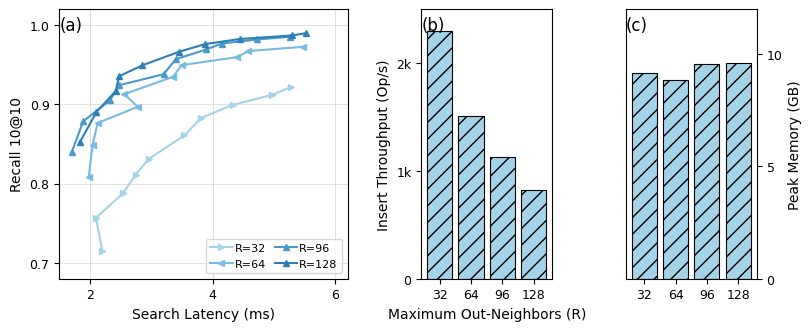

In [8]:
USE_EXAMPLE = True
filename_prefix = "./data-example" if USE_EXAMPLE else "./data"
DEFAULT_L = 20

data = [
    process_pipeann(filename_prefix + "/varl_L32.txt", DEFAULT_L),
    process_pipeann(filename_prefix + "/varl_L64.txt", DEFAULT_L),
    process_pipeann(filename_prefix + "/varl_L96.txt", DEFAULT_L),
    process_pipeann(filename_prefix + "/varl_L128.txt", DEFAULT_L),
]


recall_lat = []
for i in range(len(data)):
    cur = []
    for k, v in data[i]["acc"].items():
        if k.endswith("_pages") or k.endswith("_lat"):
            continue
        lat = data[i]["acc"][k + "_lat"]
        cur.append((sum(v) / len(v), sum(lat) / len(lat))) 
    recall_lat.append(cur)

insert_tput = [sum(x["insert_tput"]) / len(x["insert_tput"]) for x in data]
memory_usages = [x["mem"][-1][1] for x in data]


import matplotlib.gridspec as gridspec

R_values_numeric = [32, 64, 96, 128]
R_values_str = [str(r) for r in R_values_numeric]


markers = ['>', '<', '^', '^'] 

plot_colors = ['#a4d3e8', '#76bce0', '#4999c9', '#2f7fb5']
legend_labels = [f'R={r}' for r in R_values_numeric]

fig = plt.figure(figsize=(9, 3.5)) 
gs = gridspec.GridSpec(1, 3, width_ratios=[2.2, 1, 1], wspace=0.4) 

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

for i in range(len(recall_lat)):
    r_data = recall_lat[i]
    recalls = [item[0] for item in r_data]
    latencies = [item[1] for item in r_data]
    ax1.plot(latencies, recalls, marker=markers[i], color=plot_colors[i], label=legend_labels[i], markersize=5, linewidth=1.5)

ax1.set_xlabel('Search Latency (ms)', fontsize=10)
ax1.set_ylabel('Recall 10@10', fontsize=10)
ax1.set_title('(a)', loc='left', fontsize=12, y=1.0, pad=-15) 

ax1.set_xticks([0, 2, 4, 6])
ax1.set_yticks([0.7, 0.8, 0.9, 1.0])
ax1.set_xlim([1.5, 6.2]) 
ax1.set_ylim([0.68, 1.02])
ax1.legend(loc='lower right', ncol=2, fontsize=8, columnspacing=0.8, handletextpad=0.2) 
ax1.grid(True, linestyle='-', linewidth=0.5, color='lightgray')
ax1.tick_params(axis='both', which='major', labelsize=9)


bar_color = plot_colors[0] 
ax2.bar(R_values_str, insert_tput, color=bar_color, hatch='//', edgecolor='black', linewidth=0.8)
ax2.set_xlabel('Maximum Out-Neighbors (R)', fontsize=10)
ax2.set_ylabel('Insert Throughput (Op/s)', fontsize=10)
ax2.set_title('(b)', loc='left', fontsize=12, y=1.0, pad=-15)

ax2.set_yticks([0, 1000, 2000])
ax2.set_yticklabels(['0', '1k', '2k'])
ax2.set_ylim([0, 2500])
ax2.tick_params(axis='both', which='major', labelsize=9)



ax3.bar(R_values_str, memory_usages, color=bar_color, hatch='//', edgecolor='black', linewidth=0.8)

ax3.set_ylabel('Peak Memory (GB)', fontsize=10)
ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
ax3.set_title('(c)', loc='left', fontsize=12, y=1.0, pad=-15)

ax3.set_yticks([0, 5, 10])
ax3.set_ylim([0, 12]) 
ax3.set_xticklabels(R_values_str) 
ax3.tick_params(axis='both', which='major', labelsize=9)



## Figure 12

This figure requires that you run `fig12.sh` beforehand.

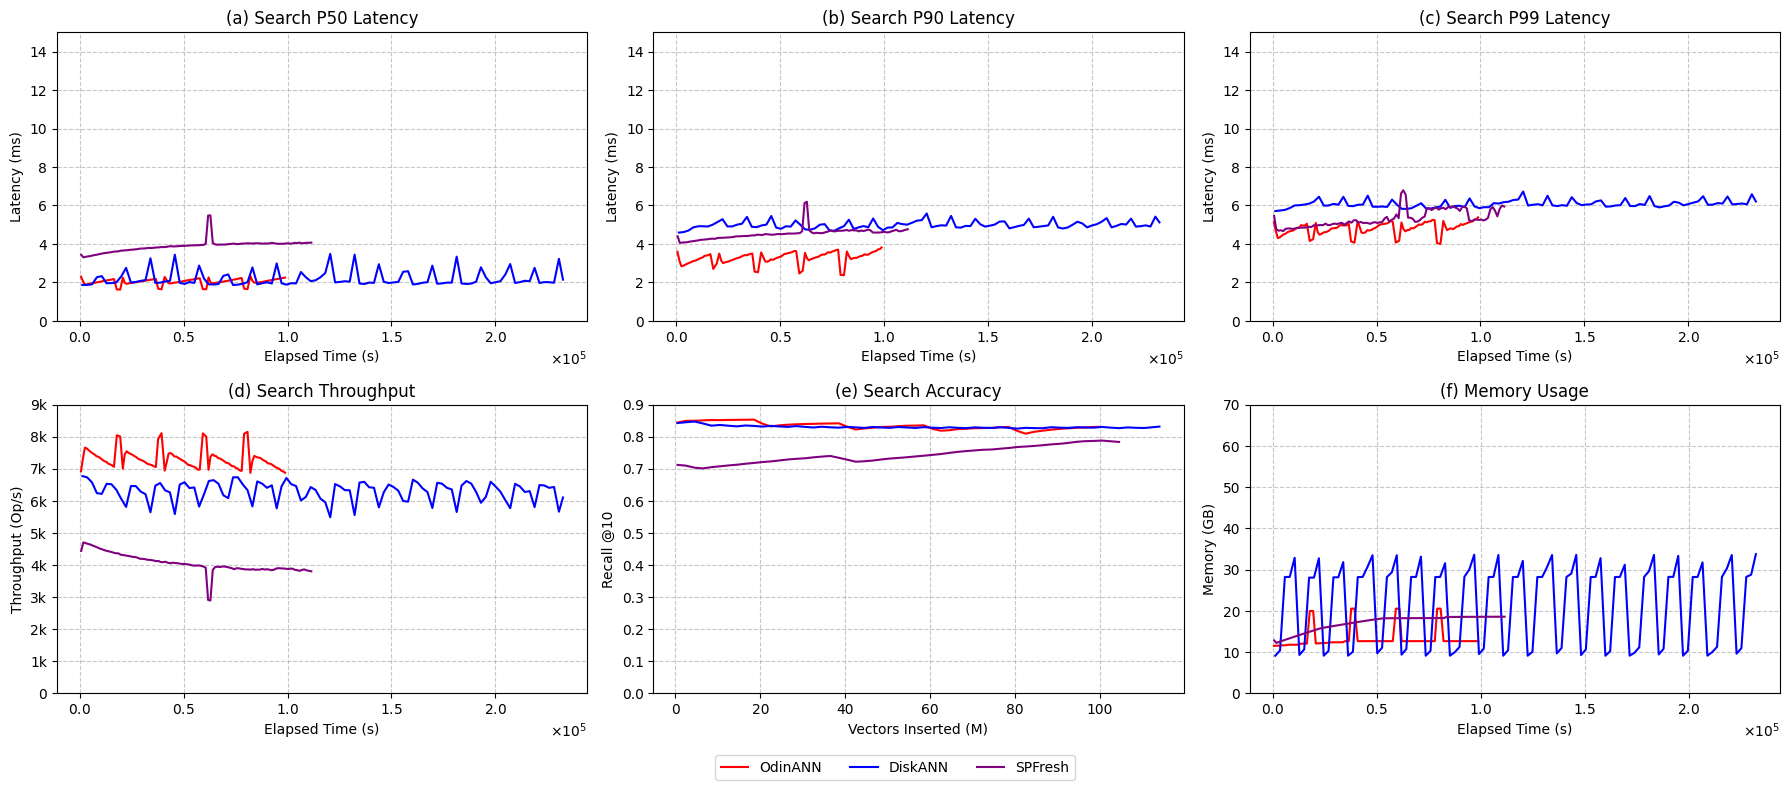

In [9]:
USE_EXAMPLE = True
filename_prefix = "./data-example" if USE_EXAMPLE else "./data"
DEFAULT_L = 20

data = [
    process_pipeann(filename_prefix + "/OdinANN-workload-change.txt", DEFAULT_L),
    process_pipeann(filename_prefix + "/DiskANN-workload-change.txt", DEFAULT_L),
    process_spann(filename_prefix + "/SPFresh-workload-change.txt", DEFAULT_L)
]

fig, axs = plt.subplots(2, 3, figsize=(18, 8))
for name, parsed_data, color in zip(sysname, data, colors):
    plot_performance_dashboard(fig, axs, parsed_data, DEFAULT_L, name, color, 100, 15, 9000, 0.9, 70)

handles, labels = [], []
for ax_row in axs:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        for i, label_item in enumerate(l):
            if label_item not in labels: 
                labels.append(label_item)
                handles.append(h[i])

if handles: 
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) 

